In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [3]:
modis = pd.read_csv("fire_archive_M-C61_720765.csv")
viirs_n20 = pd.read_csv("fire_archive_J1V-C2_720766.csv")

In [4]:
print("MODIS shape:", modis.shape)
print("VIIRS shape:", viirs_n20.shape)

modis.head()
viirs_n20.head()

MODIS shape: (514360, 15)
VIIRS shape: (3330822, 15)


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,22.12196,92.67233,355.08,0.63,0.72,2018-04-01,606,N20,VIIRS,n,2,300.37,30.87,D,0
1,23.33892,91.67667,340.80,0.69,0.74,2018-04-01,606,N20,VIIRS,n,2,296.10,7.17,D,0
2,22.10355,92.81759,338.69,0.62,0.72,2018-04-01,606,N20,VIIRS,n,2,300.20,7.17,D,0
3,22.58846,92.51312,337.59,0.63,0.72,2018-04-01,606,N20,VIIRS,n,2,299.01,6.89,D,0
4,23.48252,93.35831,350.43,0.54,0.68,2018-04-01,606,N20,VIIRS,n,2,298.23,7.44,D,0


In [5]:
print("MODIS columns:\n", modis.columns.tolist())
print("\nVIIRS columns:\n", viirs_n20.columns.tolist())

MODIS columns:
 ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']

VIIRS columns:
 ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']


In [6]:
COMMON_COLS = [
    "latitude",
    "longitude",
    "brightness",
    "acq_date",
    "acq_time",
    "satellite",
    "instrument",
    "confidence",
    "frp",
    "daynight"
]

modis = modis[COMMON_COLS]
viirs_n20 = viirs_n20[COMMON_COLS]

In [7]:
viirs_map = {"l":30, "n":60, "h":90}

viirs_n20["confidence"] = (
    viirs_n20["confidence"]
    .astype(str)
    .str.lower()
    .map(viirs_map)
)

In [8]:
viirs_n20["confidence"].unique()

array([60, 30, 90])

In [9]:
modis["sensor"] = "MODIS"
viirs_n20["sensor"] = "VIIRS"

In [10]:
fires = pd.concat(
    [modis, viirs_n20],
    ignore_index=True
)

In [11]:
fires["acq_date"] = pd.to_datetime(fires["acq_date"])
fires["acq_time"] = fires["acq_time"].astype(str).str.zfill(4)

fires["hour"] = fires["acq_time"].str[:2].astype(int)

In [12]:
fires = fires.drop_duplicates(
    subset=["latitude","longitude","acq_date","acq_time"]
)

In [13]:
print(fires.shape)
print(fires["sensor"].value_counts())
fires.describe()

(3845181, 12)
sensor
VIIRS    3330821
MODIS     514360
Name: count, dtype: int64


,latitude,longitude,brightness,acq_date,confidence,frp,hour
count,3.845181e+06,3.845181e+06,3.845181e+06,3845181,3.845181e+06,3.845181e+06,3.845181e+06
mean,2.349439e+01,8.059507e+01,3.303217e+02,2021-02-21 02:19:35.934032384,5.698785e+01,9.021622e+00,1.057331e+01
min,6.924360e+00,6.845260e+01,2.079300e+02,2018-01-01 00:00:00,0.000000e+00,0.000000e+00,3.000000e+00
25%,2.035423e+01,7.609458e+01,3.157700e+02,2019-11-02 00:00:00,6.000000e+01,2.170000e+00,7.000000e+00
50%,2.334695e+01,7.943219e+01,3.338900e+02,2021-03-24 00:00:00,6.000000e+01,4.270000e+00,8.000000e+00
75%,2.710475e+01,8.378689e+01,3.413000e+02,2022-04-27 00:00:00,6.000000e+01,8.380000e+00,1.900000e+01
max,3.497340e+01,9.720707e+01,5.057000e+02,2023-12-31 00:00:00,1.000000e+02,6.961800e+03,2.200000e+01
std,4.960683e+00,5.632707e+00,1.669942e+01,NaN,1.367874e+01,3.031255e+01,5.539224e+00


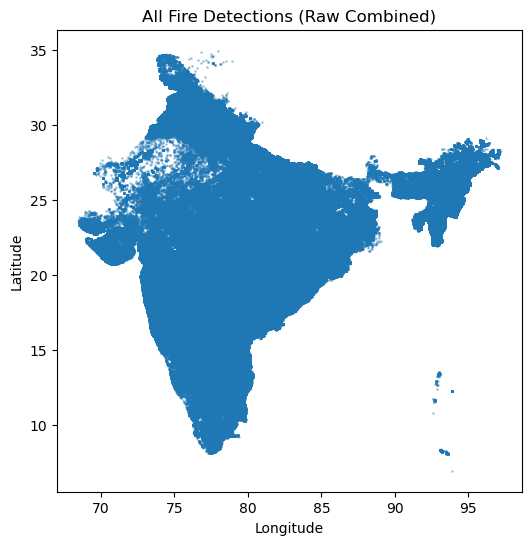

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(fires["longitude"], fires["latitude"], s=1, alpha=0.3)
plt.title("All Fire Detections (Raw Combined)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**punjab**


In [26]:
LAT_MIN, LAT_MAX = 29.7, 32.5
LON_MIN, LON_MAX = 74.0, 76.5

In [27]:
punjab = fires[
    (fires["latitude"] >= LAT_MIN) &
    (fires["latitude"] <= LAT_MAX) &
    (fires["longitude"] >= LON_MIN) &
    (fires["longitude"] <= LON_MAX)
].copy()

In [28]:
print("Before filtering:", fires.shape)
print("After Punjab filter:", punjab.shape)

Before filtering: (3845181, 12)
After Punjab filter: (578631, 12)


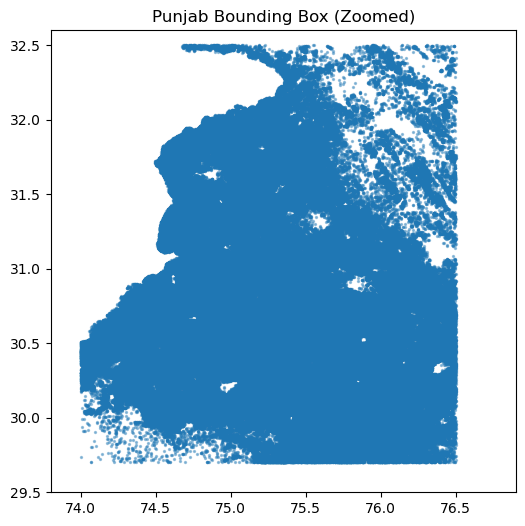

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(punjab["longitude"], punjab["latitude"], s=2, alpha=0.4)

plt.xlim(73.8, 76.9)
plt.ylim(29.5, 32.6)

plt.title("Punjab Bounding Box (Zoomed)")
plt.show()

In [30]:
punjab["month"] = punjab["acq_date"].dt.month

punjab = punjab[
    (punjab["month"] == 10) | (punjab["month"] == 11)
]

In [31]:
print("After seasonal filtering:", punjab.shape)

After seasonal filtering: (423589, 13)


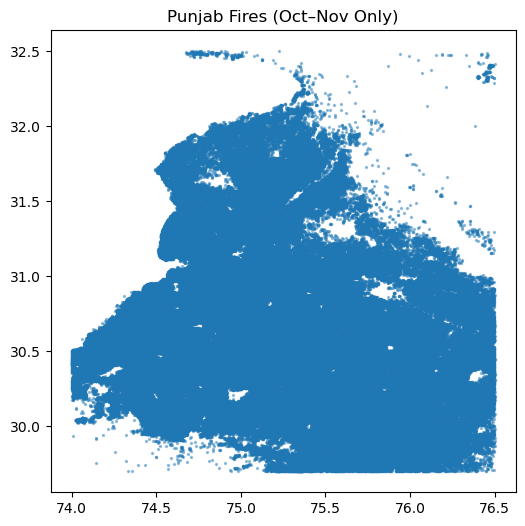

In [32]:
plt.figure(figsize=(6,6))
plt.scatter(punjab["longitude"], punjab["latitude"], s=2, alpha=0.4)
plt.title("Punjab Fires (Oct–Nov Only)")
plt.show()

In [33]:
print(punjab.shape)

(423589, 13)


In [34]:
hour_counts = punjab["hour"].value_counts().sort_index()

hour_counts

hour
4          8
5       2859
6       3633
7     142010
8     268443
9       6073
16         4
17        10
19        47
20       365
21       137
Name: count, dtype: int64

In [38]:
punjab["hour_ist"] = (punjab["hour"] + 5) % 24

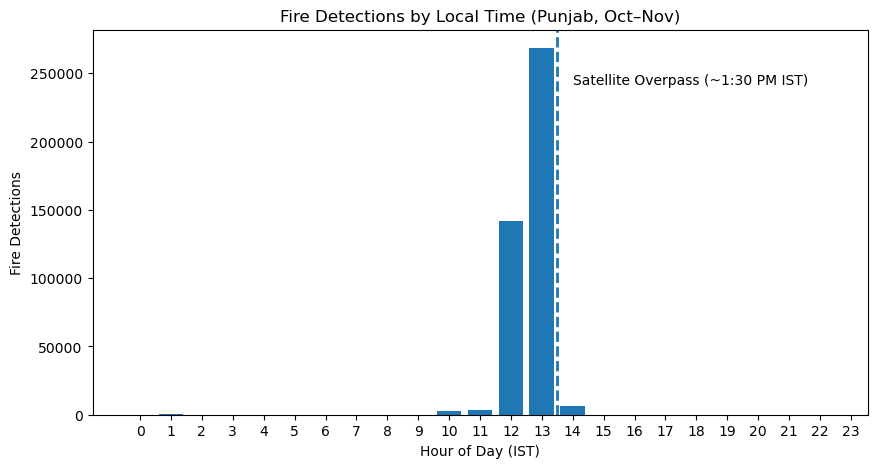

In [39]:
hour_counts_ist = punjab["hour_ist"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(hour_counts_ist.index, hour_counts_ist.values)

plt.axvline(x=13.5, linestyle="--", linewidth=2)
plt.text(14, max(hour_counts_ist.values)*0.9,
         "Satellite Overpass (~1:30 PM IST)")

plt.xlabel("Hour of Day (IST)")
plt.ylabel("Fire Detections")
plt.title("Fire Detections by Local Time (Punjab, Oct–Nov)")
plt.xticks(range(24))
plt.show()

**something really interesting over here**

In [37]:
punjab.groupby("sensor")["hour"].mean()

sensor
MODIS    7.715294
VIIRS    7.644349
Name: hour, dtype: float64

In [46]:
GRID_SIZE = 0.07

punjab["grid_x"] = ((punjab["longitude"] - LON_MIN) / GRID_SIZE).astype(int)
punjab["grid_y"] = ((punjab["latitude"] - LAT_MIN) / GRID_SIZE).astype(int)

In [47]:
punjab["grid_id"] = (
    punjab["grid_x"].astype(str) + "_" +
    punjab["grid_y"].astype(str)
)

In [48]:
punjab["grid_id"].nunique()

1040

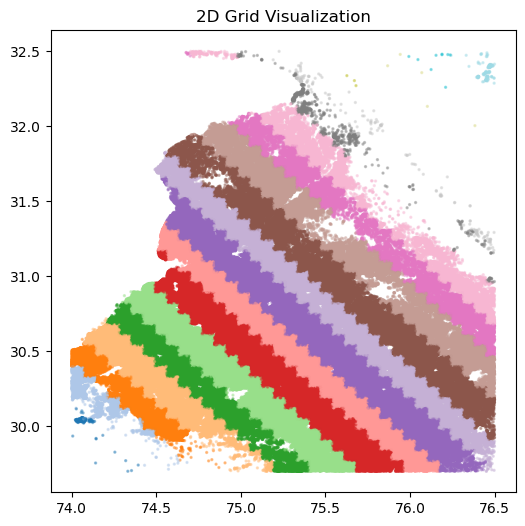

In [51]:
plt.figure(figsize=(6,6))

plt.scatter(
    punjab["longitude"],
    punjab["latitude"],
    c=punjab["grid_x"] + punjab["grid_y"],
    s=2,
    cmap="tab20",
    alpha=0.4
)

plt.title("2D Grid Visualization")
plt.show()

In [52]:
pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 8.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 16.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 68.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.5 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [53]:
import geopandas as gpd
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(punjab.longitude, punjab.latitude)]

gdf = gpd.GeoDataFrame(punjab, geometry=geometry, crs="EPSG:4326")

In [54]:
gdf = gdf.to_crs(epsg=3857)

In [55]:
GRID_SIZE = 7000  # meters

gdf["grid_x"] = (gdf.geometry.x // GRID_SIZE).astype(int)
gdf["grid_y"] = (gdf.geometry.y // GRID_SIZE).astype(int)

gdf["grid_id"] = (
    gdf["grid_x"].astype(str) + "_" +
    gdf["grid_y"].astype(str)
)

<Axes: >

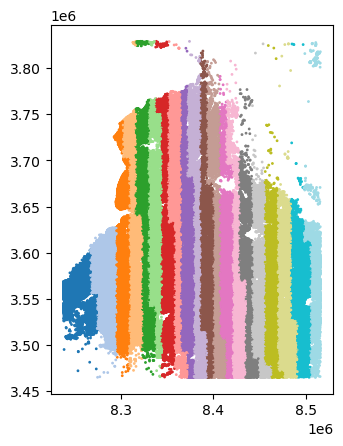

In [56]:
gdf.plot(markersize=1, column="grid_id", cmap="tab20")

In [57]:
from shapely.geometry import box

GRID_SIZE = 7000  # meters

unique_cells = gdf[["grid_x","grid_y"]].drop_duplicates()

grid_polygons = []

for _, row in unique_cells.iterrows():
    x = row["grid_x"] * GRID_SIZE
    y = row["grid_y"] * GRID_SIZE
    
    grid_polygons.append(
        box(x, y, x + GRID_SIZE, y + GRID_SIZE)
    )

grid_df = gpd.GeoDataFrame(unique_cells, geometry=grid_polygons, crs=gdf.crs)

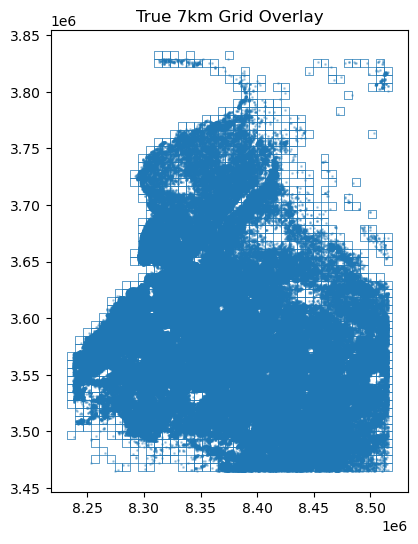

In [58]:
ax = grid_df.boundary.plot(figsize=(6,6), linewidth=0.5)

gdf.plot(ax=ax, markersize=1, alpha=0.3)

plt.title("True 7km Grid Overlay")
plt.show()

In [59]:
grid_counts = (
    gdf.groupby(["grid_x","grid_y"])
    .size()
    .reset_index(name="fire_count")
)

In [60]:
grid_df = grid_df.merge(
    grid_counts,
    on=["grid_x","grid_y"],
    how="left"
)

grid_df["fire_count"] = grid_df["fire_count"].fillna(0)

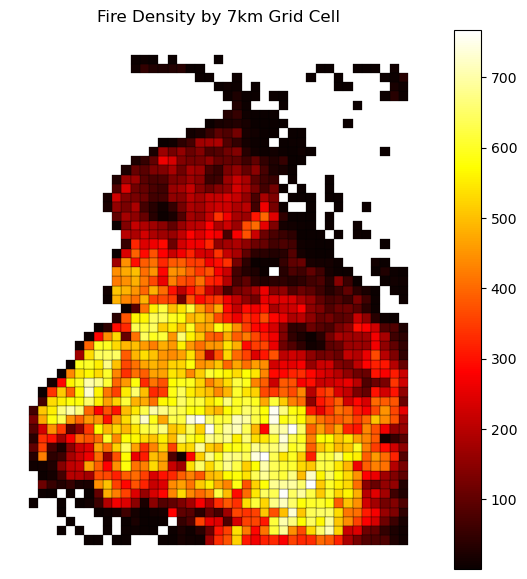

In [61]:
ax = grid_df.plot(
    column="fire_count",
    cmap="hot",
    figsize=(7,7),
    legend=True,
    edgecolor="black",
    linewidth=0.2
)

plt.title("Fire Density by 7km Grid Cell")
plt.axis("off")
plt.show()

In [62]:
gdf["year"] = gdf["acq_date"].dt.year
gdf["week"] = gdf["acq_date"].dt.isocalendar().week

In [63]:
grid_week = (
    gdf.groupby(["grid_id","year","week"])
    .size()
    .reset_index(name="fire_count")
)

In [64]:
grid_week.head(20)

,grid_id,year,week,fire_count
0,1176_499,2023,41,1
1,1176_503,2019,43,1
2,1176_503,2019,44,2
3,1176_503,2019,47,1
4,1176_503,2020,43,1
5,1176_503,2021,46,1
6,1176_503,2023,45,2
7,1176_504,2018,43,3
8,1176_504,2018,44,1
9,1176_504,2018,47,1


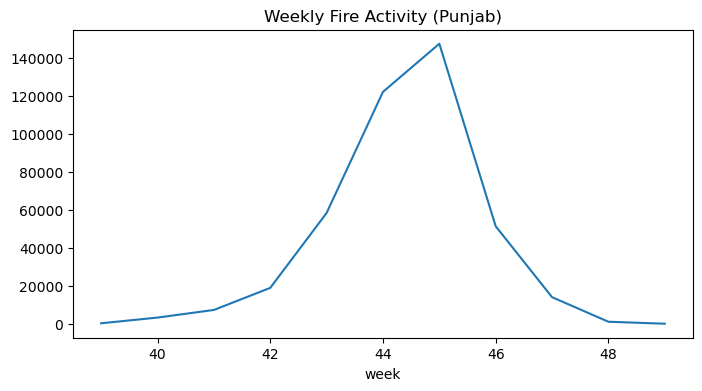

In [65]:
weekly_activity = (
    grid_week.groupby("week")["fire_count"].sum()
)

weekly_activity.plot(figsize=(8,4), title="Weekly Fire Activity (Punjab)")
plt.show()